In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import joblib




features = pd.read_csv("../data/customer_features.csv")
train = pd.read_csv("../data/customer_clv_train.csv")

df = train.merge(features, on="cust_id", how="left")

In [29]:
# churn target
df["returned"] = (df["revenue_2018_2019"] > 0).astype(int)

In [30]:
X = df.drop(columns=["cust_id", "revenue_2018_2019", "returned"])
y = df["returned"]

In [31]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# LightGBM

In [40]:

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

lgb_model = lgb.LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    num_leaves=64,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 34106, number of negative: 59166
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4948
[LightGBM] [Info] Number of data points in the train set: 93272, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.365662 -> initscore=-0.550874
[LightGBM] [Info] Start training from score -0.550874


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.02
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [41]:
p_val_lgb = lgb_model.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, p_val_lgb)
ll = log_loss(y_val, p_val_lgb)

print("AUC:", auc)
print("Log loss:", ll)

AUC: 0.7147619828755025
Log loss: 0.6041384428031163


In [42]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
11,avg_size,7238
14,recency_days,5840
23,revenue_recency_ratio,5304
2,max_item_revenue,4981
22,frequency_recency_ratio,4509
5,total_discount,4406
24,discount_per_item,4391
1,avg_item_revenue,4367
0,total_revenue,4118
18,avg_order_value,3697


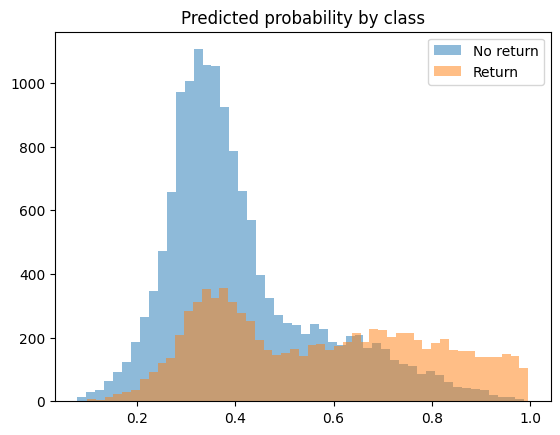

In [37]:
plt.hist(p_val_lgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_lgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# XGBoost

In [32]:
xgb_model = xgb.XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

p_val_xgb = xgb_model.predict_proba(X_val)[:,1]

print("XGBoost AUC:", roc_auc_score(y_val, p_val_xgb))
print("XGBoost LogLoss:", log_loss(y_val, p_val_xgb))

XGBoost AUC: 0.718488325009567
XGBoost LogLoss: 0.576025664930877


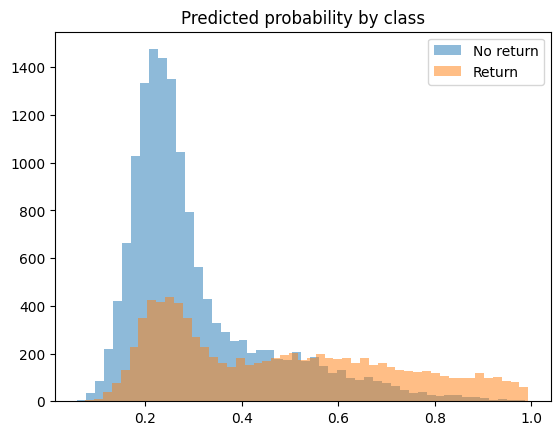

In [33]:
plt.hist(p_val_xgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_xgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# CatBoost

In [ ]:
cat_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    verbose=False,
    random_state=42
)

cat_model.fit(X_train, y_train)

p_val_cat = cat_model.predict_proba(X_val)[:,1]

print("CatBoost AUC:", roc_auc_score(y_val, p_val_cat))
print("CatBoost LogLoss:", log_loss(y_val, p_val_cat))

CatBoost AUC: 0.7209355053233188
CatBoost LogLoss: 0.5734307830295744


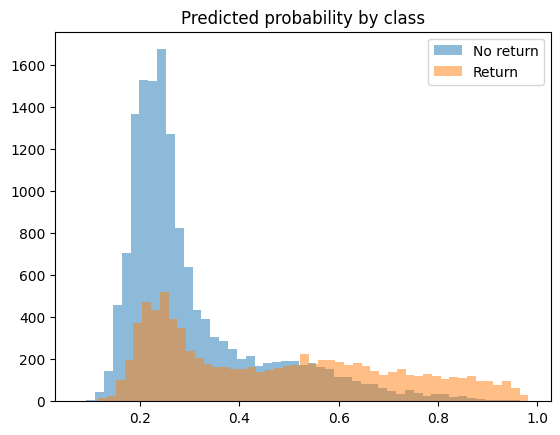

In [35]:
plt.hist(p_val_cat[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_cat[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# Comparison

In [38]:
results = {
    "LightGBM": roc_auc_score(y_val, p_val_lgb),
    "XGBoost": roc_auc_score(y_val, p_val_xgb),
    "CatBoost": roc_auc_score(y_val, p_val_cat)
}

results

{'LightGBM': 0.7147619828755025,
 'XGBoost': 0.718488325009567,
 'CatBoost': 0.7209355053233188}

# Save Models

In [ ]:
feature_cols = X.columns.tolist()

joblib.dump(feature_cols, "../models/feature_columns.pkl")

['models/feature_columns.pkl']

In [ ]:
joblib.dump(lgb_model, "../models/churn_lgb_model.pkl")
joblib.dump(xgb_model, "../models/churn_xgb_model.pkl")
joblib.dump(cat_model, "../models/churn_cat_model.pkl")

['models/churn_cat_model.pkl']